# NASDAQ Stock Data — KPI Assessment
**Assignment:** Collect share price data using Yahoo Finance API and assess its quality using KPIs.

**Companies selected from NASDAQ:**
| Company | Ticker | Period |
|---------|--------|--------|
| Apple | AAPL | Jan 2024 – Jan 2025 |
| Microsoft | MSFT | Jul 2023 – Jul 2024 |
| NVIDIA | NVDA | Apr 2024 – Apr 2025 |
| Google (Alphabet) | GOOGL | Oct 2023 – Oct 2024 |
| Meta | META | Jun 2024 – Mar 2025 |

## Step 1 — Install and Import Libraries
Run the first cell once to install yfinance. After that, you only need to run the import cell.

In [1]:
# install yfinance — only need to run this once ever
!pip install yfinance

In [2]:
# import everything we need
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

print("libraries loaded ok!")

libraries loaded ok!


## Step 2 — Download Stock Data
Each company has a **different time period** (requirement from the task).

In [3]:
# define each company: ticker -> (start date, end date)
companies = {
    'AAPL':  ('2024-01-01', '2025-01-01'),   # apple — full year 2024
    'MSFT':  ('2023-07-01', '2024-07-01'),   # microsoft — mid 2023 to mid 2024
    'NVDA':  ('2024-04-01', '2025-04-01'),   # nvidia — april 2024 to april 2025
    'GOOGL': ('2023-10-01', '2024-10-01'),   # google — oct 2023 to oct 2024
    'META':  ('2024-06-01', '2025-03-01'),   # meta — june 2024 to march 2025
}

# download and store each one in a dictionary
stock_data = {}

for ticker, (start, end) in companies.items():
    print(f"downloading {ticker}...")
    raw = yf.download(ticker, start=start, end=end, interval='1d', auto_adjust=True, progress=False)
    # keep only the closing price and flatten column names
    df = raw[['Close']].copy()
    df.columns = ['Close']
    df.index = pd.to_datetime(df.index)
    stock_data[ticker] = df
    print(f"  -> got {len(df)} trading days ({start} to {end})")

print("\nall done!")

downloading AAPL...
  -> got 252 trading days (2024-01-01 to 2025-01-01)
downloading MSFT...
  -> got 250 trading days (2023-07-01 to 2024-07-01)
downloading NVDA...
  -> got 251 trading days (2024-04-01 to 2025-04-01)
downloading GOOGL...
  -> got 251 trading days (2023-10-01 to 2024-10-01)
downloading META...
  -> got 186 trading days (2024-06-01 to 2025-03-01)

all done!


## Step 3 — Preview the Data

In [4]:
# peek at the first few rows of each stock
for ticker, df in stock_data.items():
    print(f"\n--- {ticker} ---")
    print(df.head())


--- AAPL ---
                 Close
Date                  
2024-01-02  183.731323
2024-01-03  182.355606
2024-01-04  180.039673
2024-01-05  179.317154
2024-01-08  183.652100

--- MSFT ---
                 Close
Date                  
2023-07-03  330.892670
2023-07-05  331.049255
2023-07-06  334.103790
2023-07-07  330.138855
2023-07-10  324.862030

--- NVDA ---
                Close
Date                 
2024-04-01  90.312035
2024-04-02  89.401543
2024-04-03  88.913826
2024-04-04  85.856544
2024-04-05  87.958374

--- GOOGL ---
                 Close
Date                  
2023-10-02  133.070206
2023-10-03  131.344452
2023-10-04  134.131409
2023-10-05  133.962799
2023-10-06  136.452255

--- META ---
                 Close
Date                  
2024-06-03  474.274719
2024-06-04  473.778107
2024-06-05  491.726471
2024-06-06  490.435211
2024-06-07  489.640625


## Step 4 — Descriptive Statistics

In [5]:
# basic stats for each company
# key values to report: min, max, mean, std deviation
for ticker, df in stock_data.items():
    stats = df['Close'].describe()
    print(f"\n=== {ticker} ===")
    print(f"  count (trading days): {stats['count']:.0f}")
    print(f"  mean price:           ${stats['mean']:.2f}")
    print(f"  std deviation:        ${stats['std']:.2f}")
    print(f"  minimum price:        ${stats['min']:.2f}")
    print(f"  maximum price:        ${stats['max']:.2f}")


=== AAPL ===
  count (trading days): 252
  mean price:           $205.65
  std deviation:        $25.58
  minimum price:        $163.51
  maximum price:        $257.61

=== MSFT ===
  count (trading days): 250
  mean price:           $371.81
  std deviation:        $40.41
  minimum price:        $306.23
  maximum price:        $446.81

=== NVDA ===
  count (trading days): 251
  mean price:           $120.89
  std deviation:        $17.85
  minimum price:        $76.16
  maximum price:        $149.38

=== GOOGL ===
  count (trading days): 251
  mean price:           $152.38
  std deviation:        $17.09
  minimum price:        $121.17
  maximum price:        $189.83

=== META ===
  count (trading days): 186
  mean price:           $566.70
  std deviation:        $66.17
  minimum price:        $450.80
  maximum price:        $733.73


## Step 5 — Basic Visualizations

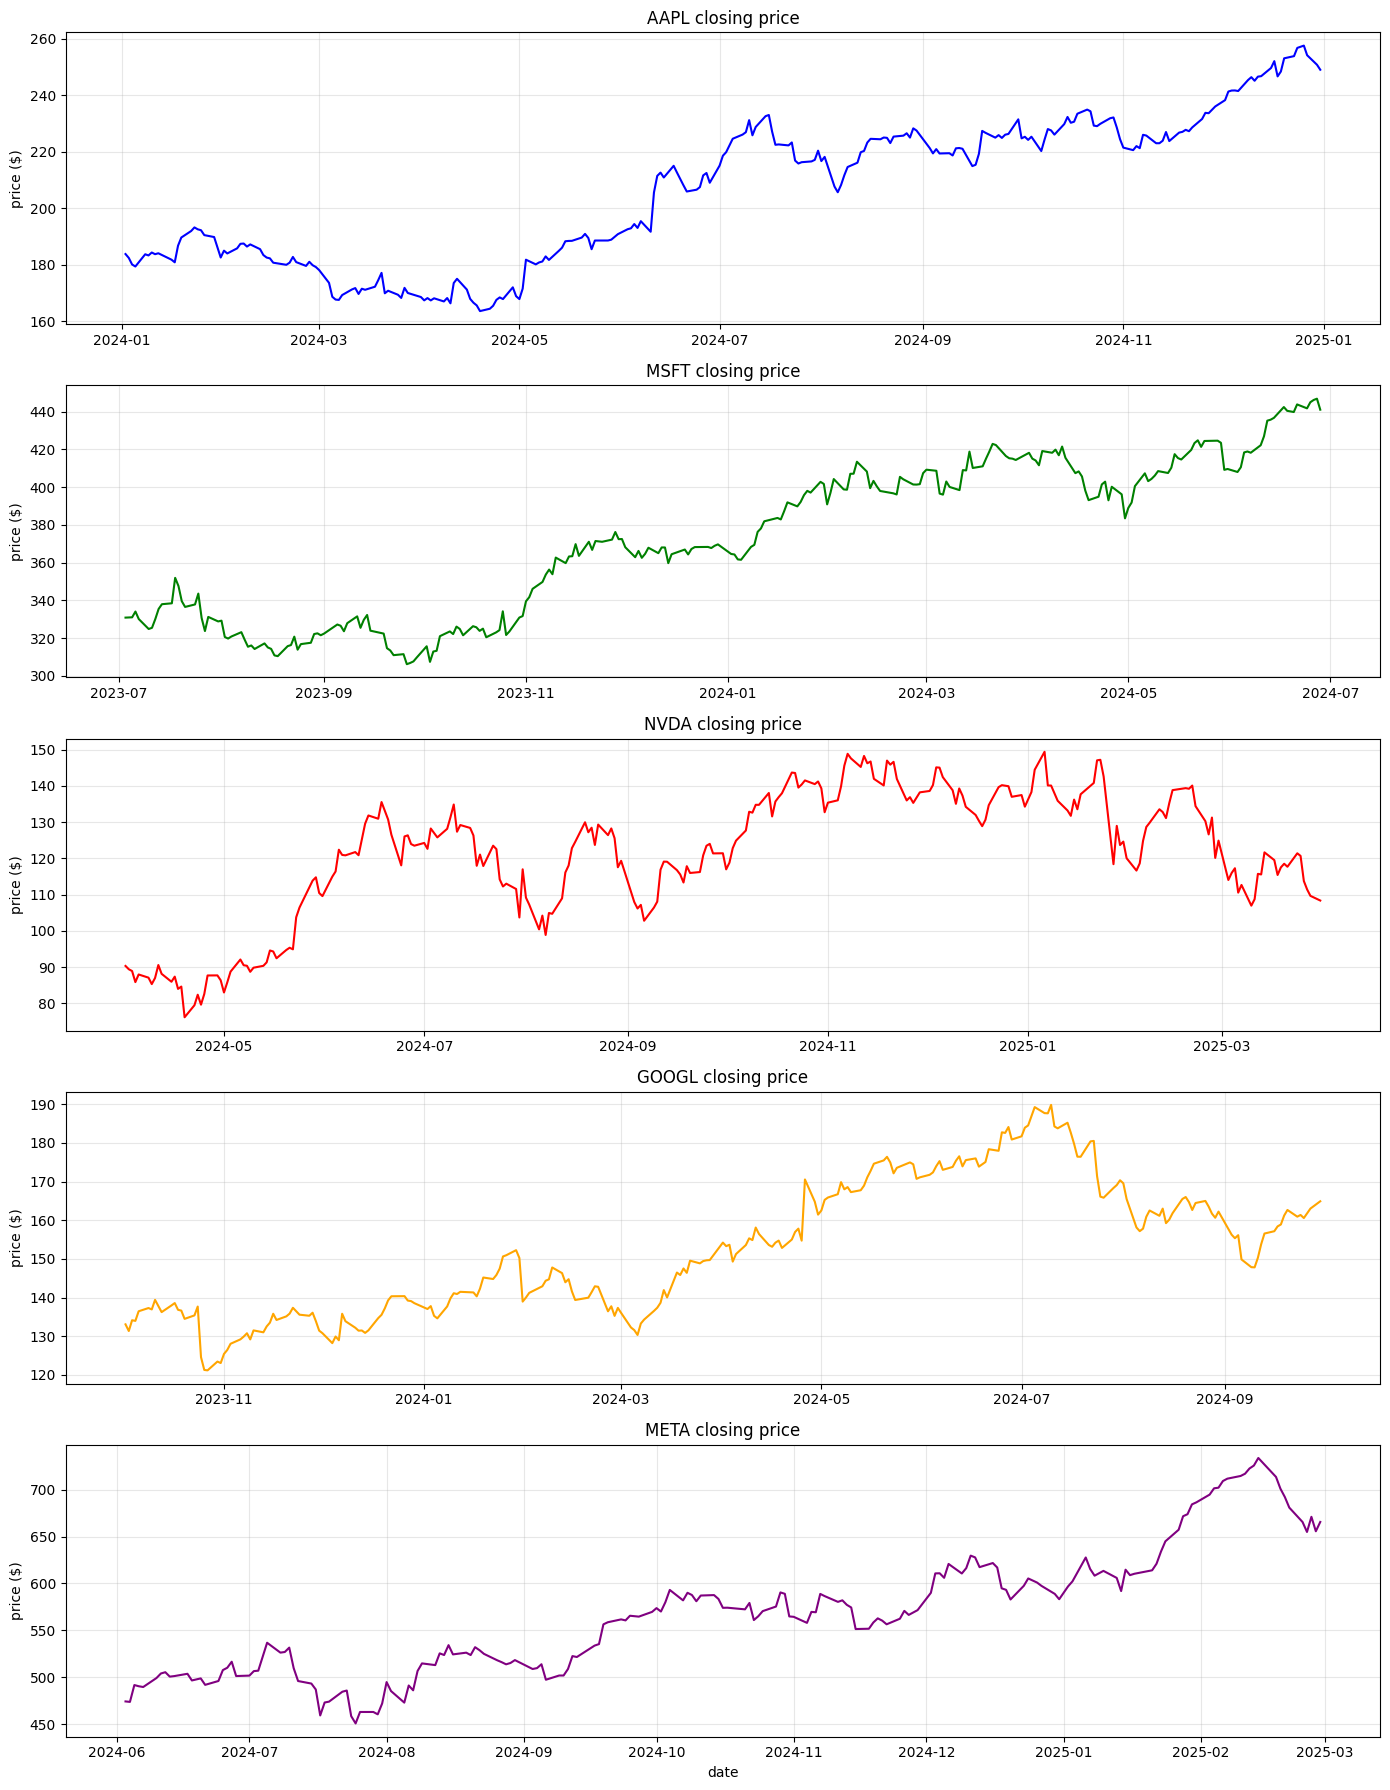

chart saved as stock_prices_individual.png


In [6]:
# plot each stock as its own chart
colors = {'AAPL': 'blue', 'MSFT': 'green', 'NVDA': 'red', 'GOOGL': 'orange', 'META': 'purple'}

fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 18))

for i, (ticker, df) in enumerate(stock_data.items()):
    axes[i].plot(df.index, df['Close'], color=colors[ticker], linewidth=1.5)
    axes[i].set_title(f'{ticker} closing price', fontsize=12)
    axes[i].set_ylabel('price ($)')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_xlabel('date')
plt.tight_layout()
plt.savefig('stock_prices_individual.png', dpi=150)
plt.show()
print("chart saved as stock_prices_individual.png")

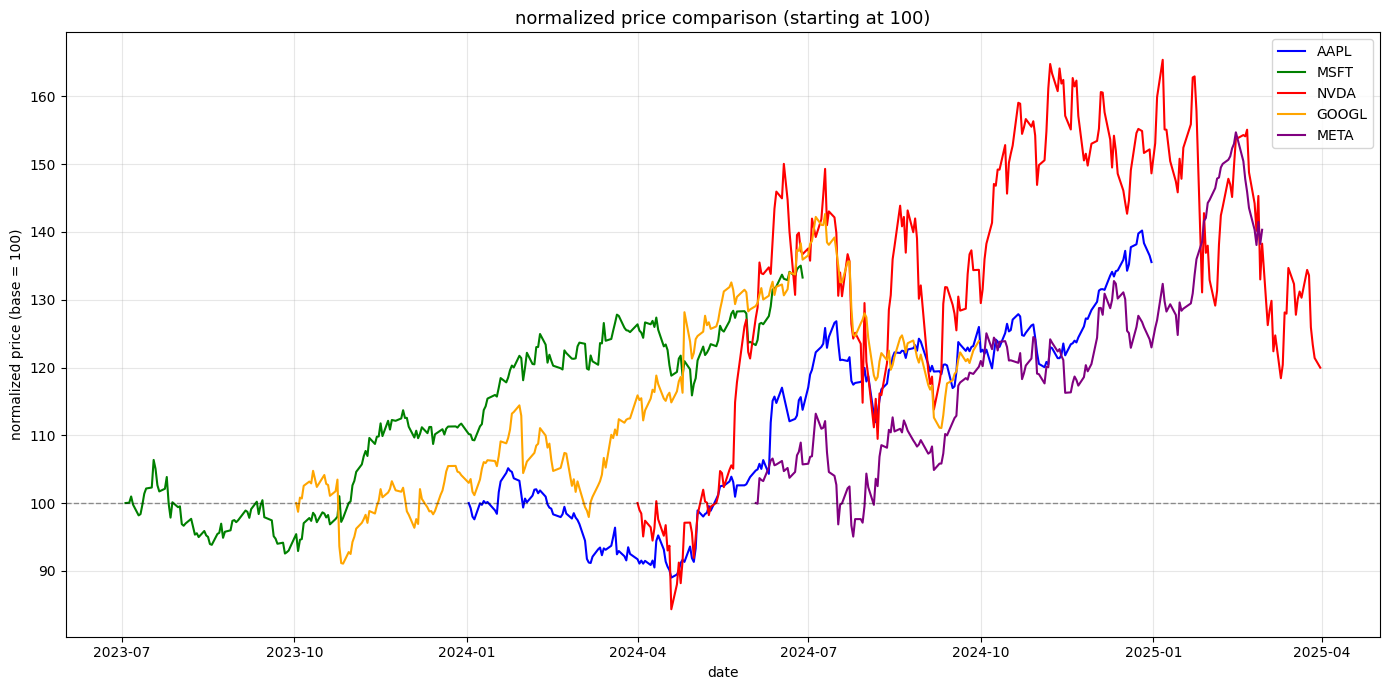

chart saved as stock_prices_normalized.png


In [7]:
# normalize prices to 100 at start so we can compare % growth on one chart
plt.figure(figsize=(14, 7))

for ticker, df in stock_data.items():
    normalized = df['Close'] / df['Close'].iloc[0] * 100
    plt.plot(df.index, normalized, label=ticker, color=colors[ticker], linewidth=1.5)

plt.axhline(y=100, color='black', linestyle='--', alpha=0.4, linewidth=1)
plt.title('normalized price comparison (starting at 100)', fontsize=13)
plt.xlabel('date')
plt.ylabel('normalized price (base = 100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('stock_prices_normalized.png', dpi=150)
plt.show()
print("chart saved as stock_prices_normalized.png")

---
# KPI Assessment
Now we check the quality of our data using 4 KPIs: **Completeness, Latency, Accuracy, Consistency**

## KPI 1 — Completeness
Are there any missing values in the data?

In [8]:
# completeness: check for missing (NaN) values
print("=== KPI 1: COMPLETENESS ===")
print(f"{'Ticker':<8} {'Total Rows':<14} {'Missing Values':<18} {'Completeness %':<15}")
print("-" * 57)

for ticker, df in stock_data.items():
    total = len(df)
    missing = df['Close'].isnull().sum()
    completeness = ((total - missing) / total) * 100
    print(f"{ticker:<8} {total:<14} {missing:<18} {completeness:.2f}%")

=== KPI 1: COMPLETENESS ===
Ticker   Total Rows     Missing Values     Completeness % 
---------------------------------------------------------
AAPL     252            0                  100.00%
MSFT     250            0                  100.00%
NVDA     251            0                  100.00%
GOOGL    251            0                  100.00%
META     186            0                  100.00%


## KPI 2 — Latency
How old is the data? What date range does it cover?

In [9]:
# latency: how old is the most recent data point?
from datetime import datetime

print("=== KPI 2: LATENCY ===")
print(f"{'Ticker':<8} {'Start Date':<14} {'End Date':<14} {'Days Covered':<14} {'Data Age (days)':<15}")
print("-" * 67)

today = datetime.today()

for ticker, df in stock_data.items():
    start = df.index.min()
    end = df.index.max()
    days_covered = (end - start).days
    data_age = (today - end.to_pydatetime().replace(tzinfo=None)).days
    print(f"{ticker:<8} {str(start.date()):<14} {str(end.date()):<14} {days_covered:<14} {data_age:<15}")

=== KPI 2: LATENCY ===
Ticker   Start Date     End Date       Days Covered   Data Age (days)
-------------------------------------------------------------------
AAPL     2024-01-02     2024-12-31     364            471            
MSFT     2023-07-03     2024-06-28     361            657            
NVDA     2024-04-01     2025-03-31     364            381            
GOOGL    2023-10-02     2024-09-30     364            563            
META     2024-06-03     2025-02-28     270            412            


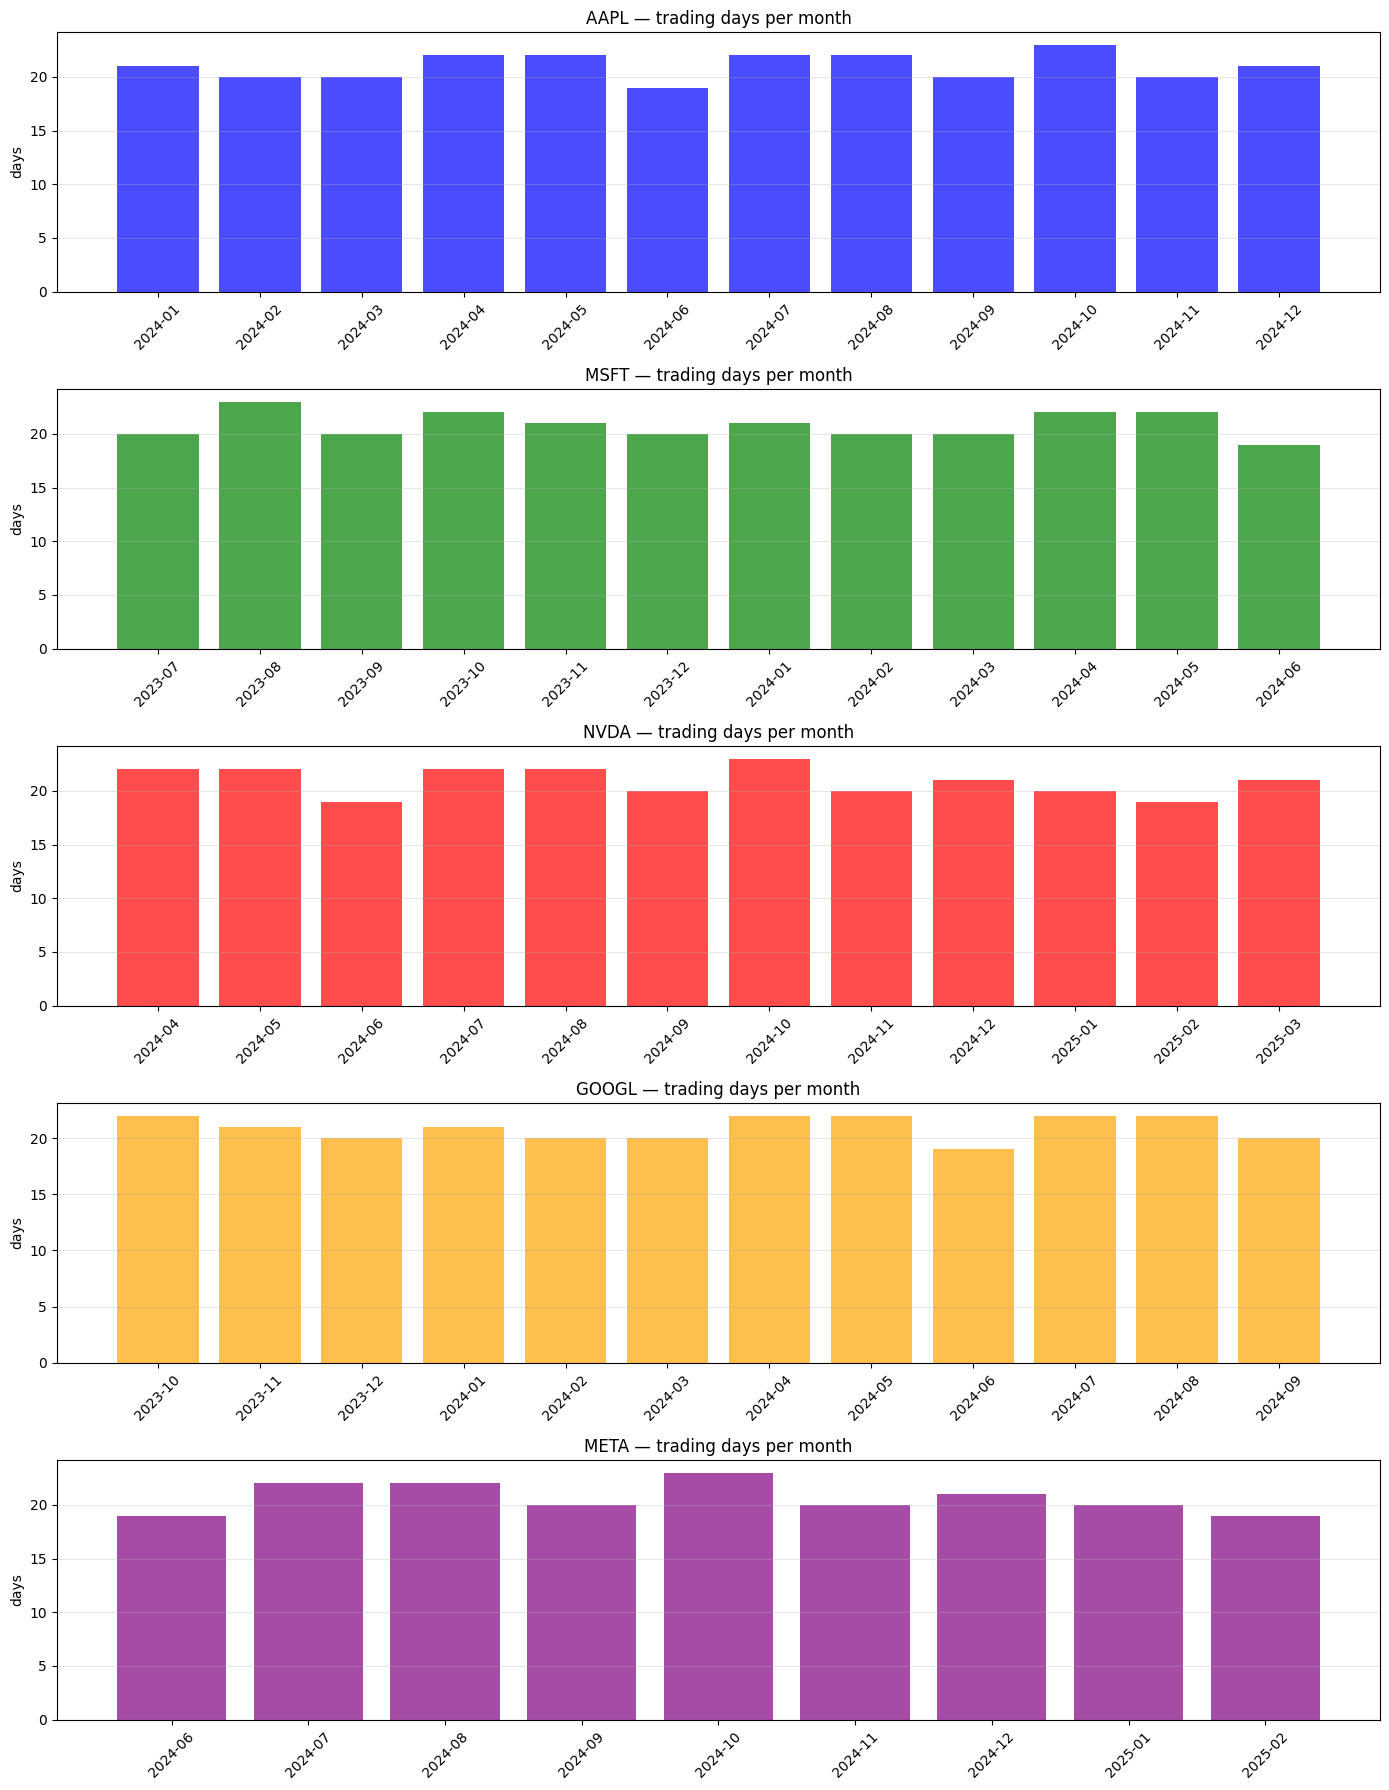

In [10]:
# plot monthly record counts to see if any months have gaps
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(14, 18))

for i, (ticker, df) in enumerate(stock_data.items()):
    monthly = df.groupby(df.index.to_period('M')).size()
    monthly.index = monthly.index.astype(str)
    axes[i].bar(monthly.index, monthly.values, color=colors[ticker], alpha=0.7)
    axes[i].set_title(f'{ticker} — trading days per month')
    axes[i].set_ylabel('days')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('latency_monthly.png', dpi=150)
plt.show()

## KPI 3 — Accuracy
Do the values make sense? Check for negative prices and extreme outliers.

In [11]:
# accuracy: look for negative prices and outliers using IQR method
print("=== KPI 3: ACCURACY ===")

for ticker, df in stock_data.items():
    total = len(df)

    # check for negative or zero prices (these would be errors)
    negative = (df['Close'] <= 0).sum()

    # detect outliers using IQR (same method from class notebook)
    Q1 = df['Close'].quantile(0.25)
    Q3 = df['Close'].quantile(0.75)
    IQR = Q3 - Q1
    outliers = ((df['Close'] < Q1 - 1.5 * IQR) | (df['Close'] > Q3 + 1.5 * IQR)).sum()
    outlier_rate = (outliers / total) * 100

    accuracy_rate = ((total - negative) / total) * 100

    print(f"\n--- {ticker} ---")
    print(f"  negative/zero prices: {negative}")
    print(f"  outliers (IQR method): {outliers} ({outlier_rate:.1f}%)")
    print(f"  data accuracy rate: {accuracy_rate:.2f}%")

=== KPI 3: ACCURACY ===

--- AAPL ---
  negative/zero prices: 0
  outliers (IQR method): 0 (0.0%)
  data accuracy rate: 100.00%

--- MSFT ---
  negative/zero prices: 0
  outliers (IQR method): 0 (0.0%)
  data accuracy rate: 100.00%

--- NVDA ---
  negative/zero prices: 0
  outliers (IQR method): 0 (0.0%)
  data accuracy rate: 100.00%

--- GOOGL ---
  negative/zero prices: 0
  outliers (IQR method): 0 (0.0%)
  data accuracy rate: 100.00%

--- META ---
  negative/zero prices: 0
  outliers (IQR method): 0 (0.0%)
  data accuracy rate: 100.00%


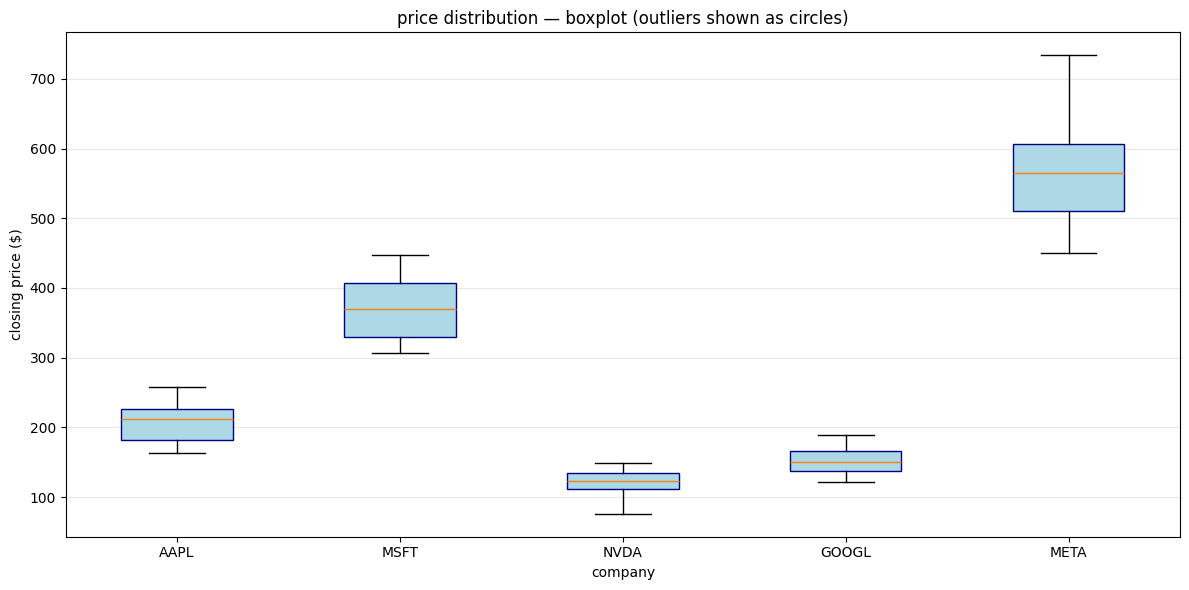

In [12]:
# box plots to visually show the price distribution and any outliers
fig, ax = plt.subplots(figsize=(12, 6))

data_to_plot = [stock_data[t]['Close'].dropna().values for t in companies.keys()]
ax.boxplot(data_to_plot, labels=list(companies.keys()), patch_artist=True,
           boxprops=dict(facecolor='lightblue', color='navy'))

ax.set_title('price distribution — boxplot (outliers shown as circles)')
ax.set_ylabel('closing price ($)')
ax.set_xlabel('company')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('accuracy_boxplot.png', dpi=150)
plt.show()

## KPI 4 — Consistency
Are the data types correct and uniform throughout?

In [13]:
# consistency: check data types and look for sudden huge price jumps
print("=== KPI 4: CONSISTENCY ===")

for ticker, df in stock_data.items():
    print(f"\n--- {ticker} ---")
    print(f"  data type of Close: {df['Close'].dtype}")
    print(f"  index type: {type(df.index).__name__}")

    # check for duplicate dates
    duplicates = df.index.duplicated().sum()
    print(f"  duplicate dates: {duplicates}")

    # check daily % change — flag any day with >15% move as suspicious
    daily_change = df['Close'].pct_change().abs() * 100
    suspicious = (daily_change > 15).sum()
    print(f"  days with >15% price change (suspicious): {suspicious}")

    print(f"  consistency ok: {'yes' if duplicates == 0 and suspicious == 0 else 'needs review'}")

=== KPI 4: CONSISTENCY ===

--- AAPL ---
  data type of Close: float64
  index type: DatetimeIndex
  duplicate dates: 0
  days with >15% price change (suspicious): 0
  consistency ok: yes

--- MSFT ---
  data type of Close: float64
  index type: DatetimeIndex
  duplicate dates: 0
  days with >15% price change (suspicious): 0
  consistency ok: yes

--- NVDA ---
  data type of Close: float64
  index type: DatetimeIndex
  duplicate dates: 0
  days with >15% price change (suspicious): 1
  consistency ok: needs review

--- GOOGL ---
  data type of Close: float64
  index type: DatetimeIndex
  duplicate dates: 0
  days with >15% price change (suspicious): 0
  consistency ok: yes

--- META ---
  data type of Close: float64
  index type: DatetimeIndex
  duplicate dates: 0
  days with >15% price change (suspicious): 0
  consistency ok: yes


---
# KPI Summary Table

In [14]:
# build a nice summary table of all KPIs in one place
from datetime import datetime

today = datetime.today()
summary_rows = []

for ticker, df in stock_data.items():
    total = len(df)
    missing = df['Close'].isnull().sum()
    completeness = ((total - missing) / total) * 100

    data_age = (today - df.index.max().to_pydatetime().replace(tzinfo=None)).days

    negative = (df['Close'] <= 0).sum()
    accuracy = ((total - negative) / total) * 100

    duplicates = df.index.duplicated().sum()
    suspicious = (df['Close'].pct_change().abs() * 100 > 15).sum()
    consistent = 'yes' if duplicates == 0 and suspicious == 0 else 'review'

    summary_rows.append({
        'Ticker': ticker,
        'Trading Days': total,
        'Completeness (%)': f"{completeness:.1f}%",
        'Data Age (days)': data_age,
        'Accuracy (%)': f"{accuracy:.1f}%",
        'Consistent': consistent
    })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))

Ticker  Trading Days Completeness (%)  Data Age (days) Accuracy (%) Consistent
  AAPL           252           100.0%              471       100.0%        yes
  MSFT           250           100.0%              657       100.0%        yes
  NVDA           251           100.0%              381       100.0%     review
 GOOGL           251           100.0%              563       100.0%        yes
  META           186           100.0%              412       100.0%        yes


---
# Save Data to CSV (for GitHub Data Card)

In [15]:
# combine all stocks into one csv file and save it
all_data = pd.DataFrame()

for ticker, df in stock_data.items():
    temp = df.copy()
    temp['Ticker'] = ticker
    temp = temp.reset_index()
    temp.columns = ['Date', 'Close', 'Ticker']
    all_data = pd.concat([all_data, temp], ignore_index=True)

all_data.to_csv('nasdaq_stock_data.csv', index=False)
print(f"saved {len(all_data)} rows to nasdaq_stock_data.csv")
print(all_data.head(10))

saved 1190 rows to nasdaq_stock_data.csv
        Date       Close Ticker
0 2024-01-02  183.731323   AAPL
1 2024-01-03  182.355606   AAPL
2 2024-01-04  180.039673   AAPL
3 2024-01-05  179.317154   AAPL
4 2024-01-08  183.652100   AAPL
5 2024-01-09  183.236465   AAPL
6 2024-01-10  184.275635   AAPL
7 2024-01-11  183.681793   AAPL
8 2024-01-12  184.008423   AAPL
9 2024-01-16  181.741974   AAPL
